**10. Train a deep MLP on the MNIST dataset (you can load it using keras.data sets.mnist.load_data(). See if you can get over 98% precision. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Try adding all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.**

In [16]:
!sudo apt update
!sudo apt install sqlite3

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,110 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,332 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 h

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.6 MB/s eta 0:00:00


In [18]:
!pip install optuna_integration[keras]

In [38]:
import os
import time
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import reciprocal
from tensorflow import keras
import tensorflow as tf
import optuna
from optuna_integration.keras import KerasPruningCallback
import datetime
import optuna
import keras
from keras.callbacks import EarlyStopping
from optuna_integration import KerasPruningCallback
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ModelCheckpoint
import os
from google.colab import drive

In [39]:
mnist = keras.datasets.mnist.load_data()

In [40]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:-10000]
y_train = y_train[:-10000]

assert x_train.shape == (50000, 28, 28)
assert x_val.shape == (10000, 28, 28)
assert x_test.shape == (10000, 28, 28)

assert y_train.shape == (50000,)
assert y_val.shape == (10000,)
assert y_test.shape == (10000,)

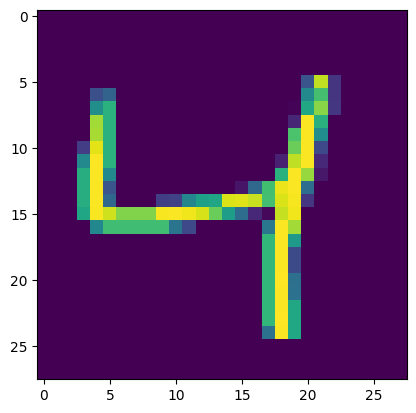

In [41]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(x_train[2])

### **LogDir**

In [42]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
LOG_DIR = '/content/drive/MyDrive/Optuna_Studies'
os.makedirs(LOG_DIR, exist_ok=True)

In [44]:
def get_run_logdir():
    import time
    RUN_ID = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(LOG_DIR, RUN_ID)


In [45]:
!sqlite3 --version

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1


In [46]:
RUN_LOGDIR = get_run_logdir()

os.makedirs(RUN_LOGDIR, exist_ok=True)

def objective(trial):
    # Clear the session to prevent memory leaks across 100 trials
    keras.backend.clear_session()

    # Suggest values of the hyperparameters using a trial object.
    n_layers = trial.suggest_int('n_layers', 1, 4)

    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))

    for i in range(n_layers):
        num_hidden = trial.suggest_int(f'n_units_l{i}', 4, 128, log=True)
        model.add(keras.layers.Dense(num_hidden, activation='relu'))

    # Output layer
    model.add(keras.layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Create a specific directory for the current trial
    trial_dir = os.path.join(RUN_LOGDIR, f"trial_{trial.number}")
    os.makedirs(trial_dir, exist_ok=True)

    # DEFINED CALLBACKS
    early_stop = EarlyStopping(monitor='val_loss', patience=3)
    pruning_cb = KerasPruningCallback(trial, "val_accuracy")
    tensorboard_cb = TensorBoard(log_dir=trial_dir)

    # ADDED: ModelCheckpoint to save the best model in the trial's folder
    checkpoint_filepath = os.path.join(trial_dir, "best_model.keras")
    checkpoint_cb = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True, # Only overwrites if the model improves
        mode='max',          # Maximize val_accuracy
        verbose=0
    )

    # Training the model
    model.fit(
        x_train, y_train,
        epochs=100,
        validation_data=(x_val, y_val),
        callbacks=[early_stop, pruning_cb, tensorboard_cb, checkpoint_cb],
        verbose=0 # Suppresses output
    )

    # Evaluate the model and return the final validation accuracy.
    score = model.evaluate(x_val, y_val, verbose=0)
    return score[1]


In [47]:

# Set up SQLite database storage in the logdir
storage_name = f"sqlite:///{os.path.join(RUN_LOGDIR, 'optuna_study.db')}"

# Create a study object backed by the SQLite database
study = optuna.create_study(
    study_name='mnist_optimization',
    storage=storage_name,
    load_if_exists=True,
    direction='maximize'
)

study.optimize(objective, n_trials=100)

# Print the best results at the end
print("Best trial:")
print("  Value: ", study.best_trial.value)
print("  Params: ", study.best_trial.params)

# If you want to load the overall best model after the study completes:
best_model_path = os.path.join(LOG_DIR, f"trial_{study.best_trial.number}", "best_model.keras")
# best_model = keras.models.load_model(best_model_path)

[I 2026-07-16 09:31:55,926] A new study created in RDB with name: mnist_optimization
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-07-16 09:33:04,181] Trial 0 finished with value: 0.9569000005722046 and parameters: {'n_layers': 3, 'n_units_l0': 19, 'n_units_l1': 33, 'n_units_l2': 5}. Best is trial 0 with value: 0.9569000005722046.
[I 2026-07-16 09:34:59,863] Trial 1 finished with value: 0.9120000004768372 and parameters: {'n_layers': 1, 'n_units_l0': 6}. Best is trial 0 with value: 0.9569000005722046.
[I 2026-07-16 09:36:07,928] Trial 2 finished with value: 0.9595999717712402 and parameters: {'n_layers': 4, 'n_units_l0': 63, 'n_units_l1': 4, 'n_units_l2': 13, 'n_units_l3': 46}. Best is trial 2 with value: 0.9595999717712402.
[I 2026-

Best trial:
  Value:  0.9789000153541565
  Params:  {'n_layers': 2, 'n_units_l0': 118, 'n_units_l1': 86}


In [49]:
%pip install optuna-dashboard


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 8.5 MB/s eta 0:00:00


In [57]:
!pip install optuna-dashboard

In [58]:
import threading
import portpicker
from google.colab import output

# 2. Find an open port on the Colab virtual machine
port = portpicker.pick_unused_port()

# 3. Define the path to your SQLite database
db_path = '/content/drive/MyDrive/Optuna_Studies/run_2026_07_16-09_31_51/optuna_study.db'

# 4. Start the dashboard server in a background thread so it doesn't block Colab
def run_dashboard():
    # We use the storage path pointing to your Google Drive DB
    !optuna-dashboard sqlite:///{db_path} --port {port}

threading.Thread(target=run_dashboard, daemon=True).start()

# 5. Display the dashboard inside a Colab cell frame
print(f"Opening dashboard on port {port}...")
output.serve_kernel_port_as_iframe(port)

Opening dashboard on port 32775...


<IPython.core.display.Javascript object>